In [88]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr

def read_sbe_cnv_to_xarray(file):
    file = Path(file)

    header = []
    data_lines = []
    in_data = False

    with open(file, "r", errors="ignore") as f:
        for line in f:
            line = line.strip()

            if line == "*END*":
                in_data = True
                continue

            if in_data:
                if line:
                    data_lines.append(line)
            else:
                header.append(line)

    # -----------------------
    # Parse column names
    # -----------------------
    names = {}
    for line in header:
        m = re.match(r"# name\s+(\d+)\s+=\s+([^:]+):", line)
        if m:
            idx = int(m.group(1))
            varname = m.group(2).strip()
            names[idx] = varname

    columns = [names[i] for i in sorted(names)]

    # -----------------------
    # Parse metadata
    # -----------------------
    attrs = {}

    for line in header:
        if line.startswith("* NMEA Latitude"):
            attrs["NMEA Latitude"] = line.split("=")[1].strip()
        elif line.startswith("* NMEA Longitude"):
            attrs["NMEA Longitude"] = line.split("=")[1].strip()
        elif line.startswith("# start_time"):
            attrs["start_time"] = line.split("=")[1].split("[")[0].strip()
        elif line.startswith("# bad_flag"):
            attrs["bad_flag"] = float(line.split("=")[1].strip())

    # -----------------------
    # Read numeric data
    # -----------------------
    from io import StringIO

    df = pd.read_csv(
        StringIO("\n".join(data_lines)),
        sep=r"\s+",
        names=columns,
        engine="python"
    )

    # Replace bad values
    if "bad_flag" in attrs:
        df = df.replace(attrs["bad_flag"], np.nan)

    # -----------------------
    # Rename useful variables
    # -----------------------
    rename = {
        "prDM": "press",
        "depSM": "depth",
        "latitude": "lat",
        "longitude": "lon",
        "t090C": "temp",
        "t190C": "temp2",
        "sal00": "sal",
        "potemp090C": "theta",
        "sigma-t00": "sigma_t",
        "sbeox0ML/L": "O2",
        "timeS": "time_elapsed",
    }

    df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})

    # Sort by pressure, just in case
    df = df.sort_values("press")

    # -----------------------
    # Make xarray Dataset
    # -----------------------
    ds = df.set_index("press").to_xarray()

    # Make lat/lon scalar coordinates if they are basically constant
    if "lat" in ds:
        lat_mean = float(ds["lat"].mean())
        ds = ds.drop_vars("lat")
        ds = ds.assign_coords(lat=lat_mean)

    if "lon" in ds:
        lon_mean = float(ds["lon"].mean())
        ds = ds.drop_vars("lon")
        ds = ds.assign_coords(lon=lon_mean)

    if "start_time" in attrs:
        ds = ds.assign_coords(time=pd.to_datetime(attrs["start_time"]))

    ds.attrs.update(attrs)

    return ds

In [49]:
from pathlib import Path

folder = Path("//thepenguin/penguin2/Data/TNB/mooring/LDEO/2017_18 Araon Cruise (ANA08C)/Data/Cruise/ANA08C/KOPRI/CTD/2017_ANA08C_TNB/CTD_processed/07_binaveraged")

In [50]:
sorted(folder.glob("*.cnv"))

[WindowsPath('//thepenguin/penguin2/Data/TNB/mooring/LDEO/2017_18 Araon Cruise (ANA08C)/Data/Cruise/ANA08C/KOPRI/CTD/2017_ANA08C_TNB/CTD_processed/07_binaveraged/ANA08C_TNB_CTD01.cnv'),
 WindowsPath('//thepenguin/penguin2/Data/TNB/mooring/LDEO/2017_18 Araon Cruise (ANA08C)/Data/Cruise/ANA08C/KOPRI/CTD/2017_ANA08C_TNB/CTD_processed/07_binaveraged/ANA08C_TNB_CTD02.cnv'),
 WindowsPath('//thepenguin/penguin2/Data/TNB/mooring/LDEO/2017_18 Araon Cruise (ANA08C)/Data/Cruise/ANA08C/KOPRI/CTD/2017_ANA08C_TNB/CTD_processed/07_binaveraged/ANA08C_TNB_CTD03.cnv'),
 WindowsPath('//thepenguin/penguin2/Data/TNB/mooring/LDEO/2017_18 Araon Cruise (ANA08C)/Data/Cruise/ANA08C/KOPRI/CTD/2017_ANA08C_TNB/CTD_processed/07_binaveraged/ANA08C_TNB_CTD04.cnv'),
 WindowsPath('//thepenguin/penguin2/Data/TNB/mooring/LDEO/2017_18 Araon Cruise (ANA08C)/Data/Cruise/ANA08C/KOPRI/CTD/2017_ANA08C_TNB/CTD_processed/07_binaveraged/ANA08C_TNB_CTD05.cnv'),
 WindowsPath('//thepenguin/penguin2/Data/TNB/mooring/LDEO/2017_18 Arao

In [51]:
ds = read_sbe_cnv_to_xarray(file="//thepenguin/penguin2/Data/TNB/mooring/LDEO/2017_18 Araon Cruise (ANA08C)/Data/Cruise/ANA08C/KOPRI/CTD/2017_ANA08C_TNB/CTD_processed/07_binaveraged/ANA08C_TNB_CTD01.cnv")

In [52]:
ds

<xarray.Dataset> Size: 134kB
Dimensions:       (press: 795)
Coordinates:
  * press         (press) float64 6kB 5.0 6.0 7.0 8.0 ... 798.0 799.0 800.0
    lat           float64 8B -74.89
    lon           float64 8B 165.1
    time          datetime64[ns] 8B 2018-03-04T09:44:26
Data variables: (12/20)
    c0S/m         (press) float64 6kB 2.742 2.754 2.768 ... 2.767 2.767 2.767
    c1S/m         (press) float64 6kB 2.703 2.695 2.688 ... 2.767 2.767 2.767
    altM          (press) float64 6kB 98.71 98.71 98.71 ... 48.22 47.22 46.24
    flECO-AFL     (press) float64 6kB 2.003 1.902 2.01 ... -0.0052 0.0195 0.0198
    O2            (press) float64 6kB 6.106 6.144 6.234 5.856 ... nan nan nan
    par           (press) float64 6kB 0.4505 0.3622 0.3108 ... nan nan nan
    ...            ...
    sigma_t       (press) float64 6kB 28.16 28.29 28.37 ... 28.06 28.06 28.06
    svCM          (press) float64 6kB 1.44e+03 1.441e+03 ... 1.453e+03 1.453e+03
    oxsatML/L     (press) float64 6kB 8.465 8.454 8.429 ... 8.478 8.478 8.478
    sal11         (press) float64 6kB 34.43 34.31 34.1 ... 34.84 34.84 34.84
    potemp190C    (press) float64 6kB -1.878 -1.872 -1.77 ... -1.922 -1.922
    flag          (press) float64 6kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    NMEA Latitude:   74 53.57 S
    NMEA Longitude:  165 04.85 E
    start_time:      Mar 04 2018 09:44:26
    bad_flag:        -9.99e-29

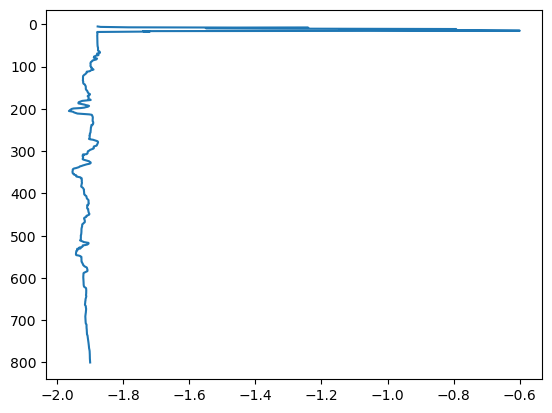

In [53]:
fig = plt.figure()
plt.plot(ds.temp,ds.press)
plt.gca().invert_yaxis()

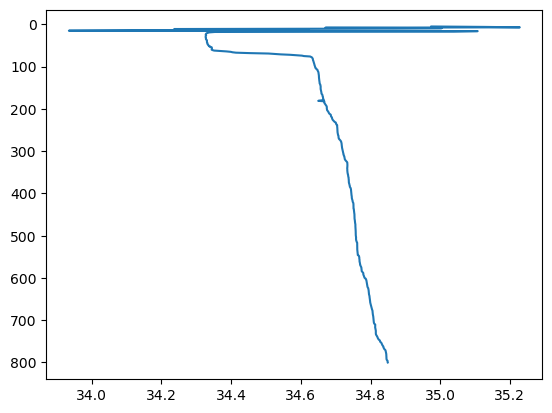

In [54]:
fig = plt.figure()
plt.plot(ds.sal,ds.press)
plt.gca().invert_yaxis()

In [55]:
# load and format all files 
casts = {}

for i, file in enumerate(sorted(folder.glob("*.cnv")), start=1):
    
    ds = read_sbe_cnv_to_xarray(file)
    
    ds.attrs["source_file"] = file.name
    ds = ds.assign_coords(station=i)
    
    casts[i] = ds

In [56]:
casts

{1: <xarray.Dataset> Size: 134kB
 Dimensions:       (press: 795)
 Coordinates:
   * press         (press) float64 6kB 5.0 6.0 7.0 8.0 ... 798.0 799.0 800.0
     lat           float64 8B -74.89
     lon           float64 8B 165.1
     time          datetime64[ns] 8B 2018-03-04T09:44:26
     station       int64 8B 1
 Data variables: (12/20)
     c0S/m         (press) float64 6kB 2.742 2.754 2.768 ... 2.767 2.767 2.767
     c1S/m         (press) float64 6kB 2.703 2.695 2.688 ... 2.767 2.767 2.767
     altM          (press) float64 6kB 98.71 98.71 98.71 ... 48.22 47.22 46.24
     flECO-AFL     (press) float64 6kB 2.003 1.902 2.01 ... -0.0052 0.0195 0.0198
     O2            (press) float64 6kB 6.106 6.144 6.234 5.856 ... nan nan nan
     par           (press) float64 6kB 0.4505 0.3622 0.3108 ... nan nan nan
     ...            ...
     sigma_t       (press) float64 6kB 28.16 28.29 28.37 ... 28.06 28.06 28.06
     svCM          (press) float64 6kB 1.44e+03 1.441e+03 ... 1.453e+03 1.453e+03


In [57]:
cast = casts[30]

In [58]:
cast

<xarray.Dataset> Size: 187kB
Dimensions:       (press: 1110)
Coordinates:
  * press         (press) float64 9kB 13.0 14.0 15.0 ... 1.121e+03 1.122e+03
    lat           float64 8B -75.18
    lon           float64 8B 164.8
    time          datetime64[ns] 8B 2018-03-09T03:28:56
    station       int64 8B 30
Data variables: (12/20)
    c0S/m         (press) float64 9kB 2.332 2.261 2.239 ... 2.783 2.783 2.783
    c1S/m         (press) float64 9kB 2.546 2.773 2.765 ... 2.783 2.783 2.783
    altM          (press) float64 9kB 98.35 98.56 98.57 98.57 ... 5.5 4.64 3.5
    flECO-AFL     (press) float64 9kB 2.466 2.418 2.464 ... -0.0083 -0.0083
    O2            (press) float64 9kB 6.495 6.765 7.197 ... 7.076 7.067 7.079
    par           (press) float64 9kB 22.5 19.65 17.24 15.12 ... nan nan nan nan
    ...            ...
    sigma_t       (press) float64 9kB 22.45 21.7 21.81 ... 28.06 28.06 28.06
    svCM          (press) float64 9kB 1.437e+03 1.436e+03 ... 1.458e+03
    oxsatML/L     (press) float64 9kB 8.568 8.618 8.72 ... 8.474 8.474 8.474
    sal11         (press) float64 9kB 32.08 34.82 34.96 ... 34.85 34.85 34.85
    potemp190C    (press) float64 9kB -1.71 -1.384 -1.6 ... -1.92 -1.92 -1.92
    flag          (press) float64 9kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    NMEA Latitude:   75 10.57 S
    NMEA Longitude:  164 48.90 E
    start_time:      Mar 09 2018 03:28:56
    bad_flag:        -9.99e-29
    source_file:     ANA08C_TNB_CTD30.cnv

In [46]:
diff = cast.sal - cast.sal11

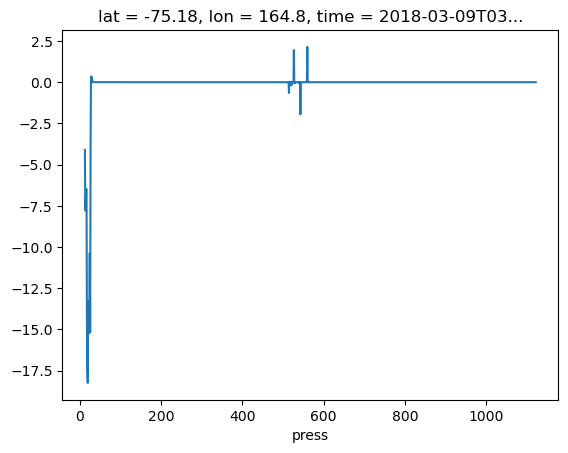

In [48]:
fig = plt.figure()
diff.plot()

In [47]:
diff

<xarray.DataArray (press: 1110)> Size: 9kB
array([-4.1093e+00, -7.7719e+00, -7.7909e+00, ...,  2.1000e-03,
        2.1000e-03,  2.0000e-03], shape=(1110,))
Coordinates:
  * press    (press) float64 9kB 13.0 14.0 15.0 ... 1.12e+03 1.121e+03 1.122e+03
    lat      float64 8B -75.18
    lon      float64 8B 164.8
    time     datetime64[ns] 8B 2018-03-09T03:28:56
    station  int64 8B 30

Text(0.5, 0, 'Sal')

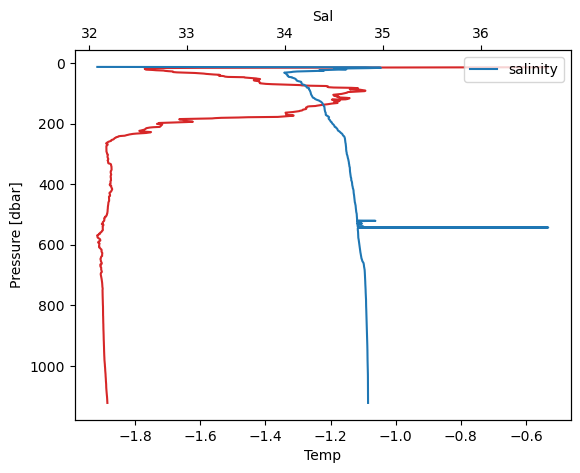

In [59]:
# updated data figure 
fig, ax = plt.subplots()
ax.plot(cast.temp,cast.press,color='tab:red',label='Temp')
ax.invert_yaxis()
ax1 = ax.twiny()
ax1.plot(cast.sal11,cast.press,color='tab:blue',label='salinity')
plt.legend()
ax.set_ylabel('Pressure [dbar]')
ax.set_xlabel('Temp')
ax1.set_xlabel('Sal')

In [63]:
%matplotlib widget

In [80]:
cast = casts[20]

In [82]:
cast

<xarray.Dataset> Size: 131kB
Dimensions:       (press: 780)
Coordinates:
  * press         (press) float64 6kB 22.0 23.0 24.0 25.0 ... 799.0 800.0 801.0
    lat           float64 8B -75.19
    lon           float64 8B 165.8
    time          datetime64[ns] 8B 2018-03-06T13:59:50
    station       int64 8B 20
Data variables: (12/20)
    c0S/m         (press) float64 6kB 7.5e-05 0.000103 0.000203 ... 2.767 2.767
    c1S/m         (press) float64 6kB 2.508 2.507 2.508 ... 2.767 2.767 2.767
    altM          (press) float64 6kB 98.72 98.73 98.72 ... 14.27 13.25 12.26
    flECO-AFL     (press) float64 6kB 5.897 5.965 6.021 ... -0.0363 -0.0363 nan
    O2            (press) float64 6kB -72.68 -72.72 -72.61 ... 6.589 6.59 6.598
    par           (press) float64 6kB nan nan nan nan nan ... 0.1023 nan nan nan
    ...            ...
    sigma_t       (press) float64 6kB -0.3157 -0.3146 -0.3101 ... 28.05 28.05
    svCM          (press) float64 6kB 1.393e+03 1.393e+03 ... 1.453e+03
    oxsatML/L     (press) float64 6kB 10.78 10.78 10.76 ... 8.478 8.478 8.478
    sal11         (press) float64 6kB 27.99 28.2 27.0 ... 34.85 34.85 34.85
    potemp190C    (press) float64 6kB 1.918 1.687 3.074 ... -1.921 -1.921 -1.921
    flag          (press) float64 6kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    NMEA Latitude:   75 11.25 S
    NMEA Longitude:  165 46.15 E
    start_time:      Mar 06 2018 13:59:50
    bad_flag:        -9.99e-29
    source_file:     ANA08C_TNB_CTD20.cnv

Text(0.5, 0, 'Sal')

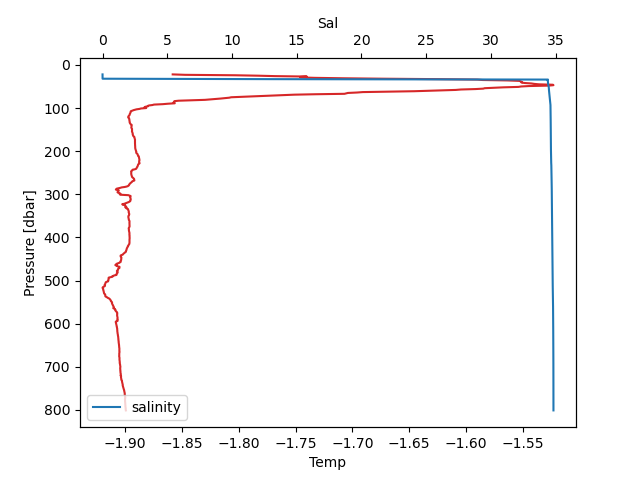

In [ ]:
cast = casts[20]

fig, ax = plt.subplots()
ax.plot(cast.temp,cast.press,color='tab:red',label='Temp')
ax.invert_yaxis()
ax1 = ax.twiny()
ax1.plot(cast.sal,cast.press,color='tab:blue',label='salinity')
plt.legend()
ax.set_ylabel('Pressure [dbar]')
ax.set_xlabel('Temp')
ax1.set_xlabel('Sal')

In [97]:
import matplotlib.pyplot as plt
import os

# directory to save figures
save_dir = "ctd_profile_TNBD_prelim"
os.makedirs(save_dir, exist_ok=True)

# loop through all casts
for key, cast in casts.items():

    fig, axes = plt.subplots(
        ncols=2,
        figsize=(10, 6),
        constrained_layout=True,
        sharey=False
    )

    # ---------------- FULL PROFILE ----------------
    ax = axes[0]

    ax.plot(cast.temp, cast.press, color='tab:red', label='Temperature')
    ax.invert_yaxis()

    ax_sal = ax.twiny()
    ax_sal.plot(cast.sal, cast.press, color='tab:blue', label='Salinity')

    ax.set_ylabel('Pressure [dbar]')
    ax.set_xlabel('Temperature')
    ax_sal.set_xlabel('Salinity')

    ax.set_title('Full Profile')

    # optional combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_sal.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

    # ---------------- UPPER 200 DBAR ----------------
    ax2 = axes[1]

    # subset near surface
    cast_surface = cast.where(cast.press <= 200, drop=True)

    ax2.plot(
        cast_surface.temp,
        cast_surface.press,
        color='tab:red',
        label='Temperature'
    )

    ax2.invert_yaxis()

    ax2_sal = ax2.twiny()
    ax2_sal.plot(
        cast_surface.sal,
        cast_surface.press,
        color='tab:blue',
        label='Salinity'
    )

    ax2.set_ylim(200, 0)

    ax2.set_xlabel('Temperature')
    ax2_sal.set_xlabel('Salinity')

    ax2.set_title('Upper 200 dbar')

    # figure title
    fig.suptitle(f'CTD Cast {key}', fontsize=14)

    # save figure
    fig.savefig(
        f"{save_dir}/cast_{key}.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.close(fig)

### Plot CTD stations on Map 

In [83]:
bath = xr.open_dataset("//thepenguin/penguin2/Data/TNB/bathymetry/bath_ross_amundsen.nc")

In [84]:
import pandas as pd
import geopandas as gpd
import cartopy.crs as ccrs
from shapely.validation import make_valid

# read fresh
gdf = gpd.read_file(
    "/Users/mblan/Documents/research/data/add_coastline_high_res_polygon_v7_11/add_coastline_high_res_polygon_v7_11.shp"
)

if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326")
else:
    gdf = gdf.to_crs("EPSG:4326")

# better than buffer(0)
gdf["geometry"] = gdf.geometry.apply(make_valid)

ice = gdf[gdf["surface"].isin(["ice shelf", "ice tongue"])]
land = gdf[gdf["surface"].isin(["land"])]

In [85]:
def subset_dateline_gdf(gdf, lat_min=-78, lat_max=-60):
    # Ross sector: 160E to 180, plus 180 to 160W
    east = gdf.cx[160:180, lat_min:lat_max]
    west = gdf.cx[-180:-160, lat_min:lat_max]

    out = pd.concat([east, west], ignore_index=True)
    return gpd.GeoDataFrame(out, crs=gdf.crs)

In [89]:
def TNB_study_site(
    bath,
    ice,
    land,
    lon_min=160,
    lon_max=200,
    lat_min=-78,
    lat_max=-60,
    figsize=(8, 6),
    central_longitude=165,
    contour_levels=None,
    n_contours=5,
    contour_min=200,
    contour_max=1200,
    contour_color="black",
    contour_lw=0.7,
    label_contours=True,
    gridline_lons=None,
    gridline_lats=None,
):
    """
    Create a reusable Terra Nova Bay / Ross Sea study-site map.

    Parameters
    ----------
    bath : xarray.Dataset
        GEBCO bathymetry dataset with variables lon, lat, elevation.
    ice, land : geopandas.GeoDataFrame
        SCAR ADD clipped/unclipped ice and land polygons.
    lon_min, lon_max, lat_min, lat_max : float
        Map extent in lon/lat.
    contour_levels : list or array, optional
        Specific bathymetry contour levels in positive meters.
        Example: [400, 600, 800, 1000]
    n_contours : int
        Number of contours if contour_levels is not provided.
    contour_min, contour_max : float
        Min/max depth contours if contour_levels is not provided.
    """

    # -----------------------------
    # Projection / figure
    # -----------------------------
    proj = ccrs.SouthPolarStereo(central_longitude=central_longitude)

    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw={"projection": proj},
        constrained_layout=True
    )

    ax.set_extent(
        [lon_min, lon_max, lat_min, lat_max],
        crs=ccrs.PlateCarree()
    )

    # -----------------------------
    # Gridlines
    # -----------------------------
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        alpha=0.5,
        linestyle="--"
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    if gridline_lons is not None:
        gl.xlocator = mticker.FixedLocator(gridline_lons)

    if gridline_lats is not None:
        gl.ylocator = mticker.FixedLocator(gridline_lats)

    # -----------------------------
    # Bathymetry subset
    # -----------------------------
    bath_sub = bath.sortby("lat").sortby("lon").sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max)
    )

    depth = -bath_sub["elevation"]

    if contour_levels is None:
        contour_levels = np.linspace(contour_min, contour_max, n_contours)

    contours = ax.contour(
        depth["lon"],
        depth["lat"],
        depth,
        levels=contour_levels,
        colors=contour_color,
        linewidths=contour_lw,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    if label_contours:
        ax.clabel(
            contours,
            fmt="%d m",
            fontsize=8,
            inline=True,
            inline_spacing=1
        )

    # -----------------------------
    # Clip coastline polygons
    # -----------------------------

    # regional subset only, no clipping
    ice_reg = subset_dateline_gdf(ice, lat_min=lat_min, lat_max=lat_max)
    land_reg = subset_dateline_gdf(land, lat_min=lat_min, lat_max=lat_max)

    # project polygons into the map projection before plotting
    ice_proj = ice_reg.to_crs(proj.proj4_init)
    land_proj = land_reg.to_crs(proj.proj4_init)

    ax.add_geometries(
        ice_proj.geometry,
        crs=proj,
        facecolor="lightgrey",
        edgecolor="k",
        linewidth=0.3,
        zorder=3,
    )

    ax.add_geometries(
        land_proj.geometry,
        crs=proj,
        facecolor="grey",
        edgecolor="k",
        linewidth=0.3,
        zorder=4,
    )

    return fig, ax

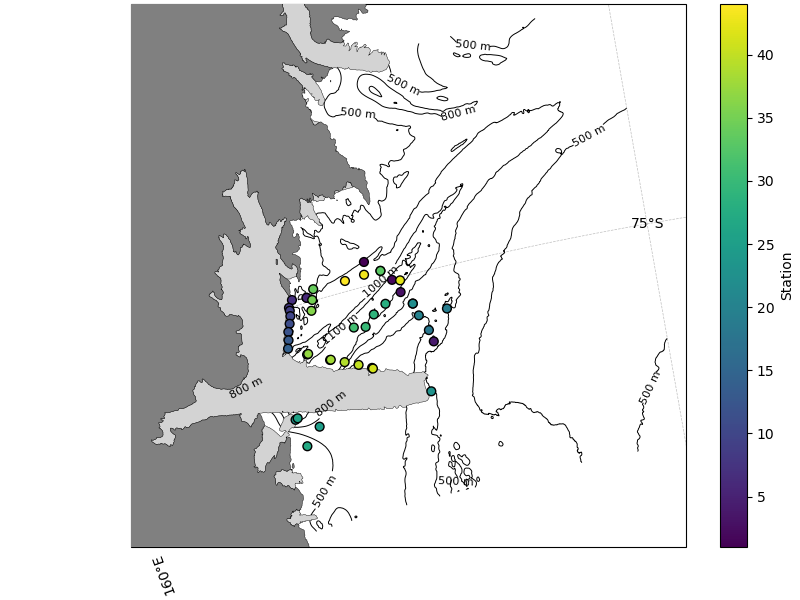

In [98]:
fig, ax = TNB_study_site(
    bath=bath,
    ice=ice,
    land=land,
    lon_min=162,
    lon_max=170,
    lat_min=-76,
    lat_max=-74,
    central_longitude=180,
    contour_levels=[500,800,1000,1100],
    gridline_lons=[160, 170, 180, -170, -160],
    gridline_lats=[-75, -72, -69, -66, -63, -60],
    label_contours=True,
)

stations = list(casts.keys())
lons = [float(ds.lon) for ds in casts.values()]
lats = [float(ds.lat) for ds in casts.values()]

sc = ax.scatter(
    lons,
    lats,
    c=stations,
    cmap='viridis',
    s=40,
    edgecolor='k',
    transform=ccrs.PlateCarree(),
    zorder=10
)

plt.colorbar(sc, ax=ax, label='Station')
plt.savefig('ctd_profile_TNBD_prelim/map.png')

In [96]:
casts[40]

<xarray.Dataset> Size: 122kB
Dimensions:       (press: 726)
Coordinates:
  * press         (press) float64 6kB 5.0 6.0 7.0 8.0 ... 728.0 729.0 730.0
    lat           float64 8B -75.33
    lon           float64 8B 164.5
    time          datetime64[ns] 8B 2018-03-11T18:26:33
    station       int64 8B 40
Data variables: (12/20)
    c0S/m         (press) float64 6kB 2.729 2.774 2.81 ... 2.764 2.764 2.764
    c1S/m         (press) float64 6kB 2.708 2.677 2.685 ... 2.764 2.764 2.764
    altM          (press) float64 6kB nan nan 98.58 98.58 ... 7.1 6.48 5.72 4.76
    flECO-AFL     (press) float64 6kB 2.667 2.847 2.907 ... nan -0.0363 -0.0363
    O2            (press) float64 6kB 6.609 6.363 6.444 6.609 ... nan nan nan
    par           (press) float64 6kB 8.488 7.219 6.112 ... nan 0.1023 0.1023
    ...            ...
    sigma_t       (press) float64 6kB 27.94 28.46 28.87 ... 28.06 28.06 28.06
    svCM          (press) float64 6kB 1.44e+03 1.441e+03 ... 1.452e+03 1.452e+03
    oxsatML/L     (press) float64 6kB 8.466 8.428 8.399 ... 8.478 8.478 8.478
    sal11         (press) float64 6kB 34.46 34.02 34.14 ... 34.84 34.85 34.84
    potemp190C    (press) float64 6kB -1.853 -1.848 -1.845 ... -1.921 -1.921
    flag          (press) float64 6kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    NMEA Latitude:   75 19.93 S
    NMEA Longitude:  164 31.16 E
    start_time:      Mar 11 2018 18:26:33
    bad_flag:        -9.99e-29
    source_file:     ANA08C_TNB_CTD40.cnv